# IMDB Sentiment Analysis — LSTM

A word-level LSTM trained on the IMDB movie reviews dataset to classify sentiment as positive or negative. The fourth project in the `deep-learning-foundations` series — moving from character-level sequence generation (RNN) to word-level sequence classification.

**Key shift from `03-rnn-text-generation`:**  
The RNN generated text character by character. This LSTM classifies an entire review (sequence of words) into a single label — positive or negative. Same LSTM architecture, completely different task structure.

**Dataset:** IMDB Movie Reviews — 25K training + 25K test reviews  
**Task:** Binary sentiment classification (positive=1, negative=0)  
**Architecture:** Embedding → LSTM → Dense(sigmoid)

## 1. Setup & Imports

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.21.0


## 2. Load the IMDB Dataset

Keras provides IMDB pre-tokenized — each review is already a list of integers where each integer represents a word. `num_words=10000` keeps only the 10,000 most frequent words, ignoring rare words that add noise.

In [2]:
NUM_WORDS = 10000

(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=NUM_WORDS)

print(f'Train samples: {len(X_train):,}')
print(f'Test samples:  {len(X_test):,}')
print(f'\nLabel distribution (train):')
print(f'  Positive: {y_train.sum():,} ({y_train.mean()*100:.1f}%)')
print(f'  Negative: {(1-y_train).sum():,} ({(1-y_train).mean()*100:.1f}%)')
print(f'\nSample review (encoded): {X_train[0][:20]}...')
print(f'Review length range: {min(len(x) for x in X_train)} to {max(len(x) for x in X_train)} words')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Train samples: 25,000
Test samples:  25,000

Label distribution (train):
  Positive: 12,500 (50.0%)
  Negative: 12,500 (50.0%)

Sample review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]...
Review length range: 11 to 2494 words


### Decode a sample review to verify data

In [3]:
word_index = keras.datasets.imdb.get_word_index()
reverse_word_index = {v+3: k for k, v in word_index.items()}
reverse_word_index[0] = '<PAD>'
reverse_word_index[1] = '<START>'
reverse_word_index[2] = '<UNK>'

def decode_review(encoded):
    return ' '.join([reverse_word_index.get(i, '?') for i in encoded])

print(f'Label: {"Positive" if y_train[0] == 1 else "Negative"}')
print(f'Review: {decode_review(X_train[0][:80])}...')

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step
Label: Positive
Review: <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as...


## 3. Pad Sequences

Reviews have variable lengths (from a few words to thousands). LSTMs need fixed-size input batches — we pad shorter reviews with zeros and truncate longer ones to `MAX_LEN`. `padding='post'` adds zeros at the end; `truncating='post'` cuts from the end.

Train shape after padding: (25000, 200)
Test shape after padding:  (25000, 200)


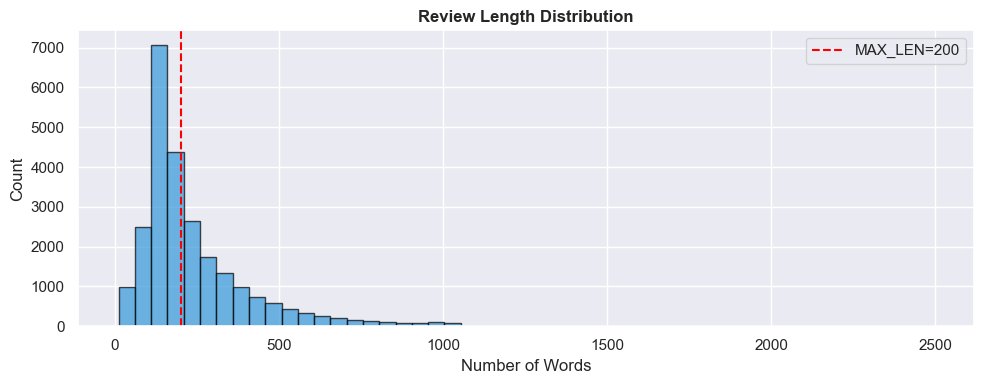

Reviews longer than 200 words: 10,677 (42.7%)


In [4]:
MAX_LEN = 200

X_train_pad = keras.preprocessing.sequence.pad_sequences(
    X_train, maxlen=MAX_LEN, padding='post', truncating='post'
)
X_test_pad = keras.preprocessing.sequence.pad_sequences(
    X_test, maxlen=MAX_LEN, padding='post', truncating='post'
)

print(f'Train shape after padding: {X_train_pad.shape}')
print(f'Test shape after padding:  {X_test_pad.shape}')

# Review length distribution
lengths = [len(x) for x in X_train]
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
plt.axvline(x=MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
plt.title('Review Length Distribution', fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Reviews longer than {MAX_LEN} words: {sum(1 for l in lengths if l > MAX_LEN):,} ({sum(1 for l in lengths if l > MAX_LEN)/len(lengths)*100:.1f}%)')

## 4. Build the LSTM Model

**Architecture:**

- `Embedding(10000, 128)` — maps each word index to a 128-dimensional vector. Words with similar meanings end up with similar vectors (learned during training)
- `SpatialDropout1D(0.2)` — drops entire word embeddings randomly, more effective than regular dropout for sequence data
- `LSTM(128)` — processes the sequence, maintaining hidden state across all 200 words. No `return_sequences` here — we only need the final hidden state for classification
- `Dense(1, sigmoid)` — outputs a single probability: 0 = negative, 1 = positive

**Why only one LSTM layer this time?**  
Classification needs one final summary of the sequence — single LSTM is sufficient. Text generation needed `return_sequences=True` on all layers because it predicted at every timestep. Classification only cares about the final output.

In [5]:
model = keras.Sequential([
    keras.layers.Embedding(NUM_WORDS, 128, input_length=MAX_LEN),
    keras.layers.SpatialDropout1D(0.2),
    keras.layers.LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Model

In [6]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)
print('Training complete.')

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 105s 282ms/step - accuracy: 0.5204 - loss: 0.6915 - val_accuracy: 0.5240 - val_loss: 0.6903
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 98s 277ms/step - accuracy: 0.5717 - loss: 0.6654 - val_accuracy: 0.5660 - val_loss: 0.6621
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 106s 301ms/step - accuracy: 0.5921 - loss: 0.6493 - val_accuracy: 0.5884 - val_loss: 0.6611
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 142s 404ms/step - accuracy: 0.7594 - loss: 0.4816 - val_accuracy: 0.5744 - val_loss: 0.6675
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 154s 438ms/step - accuracy: 0.8307 - loss: 0.3784 - val_accuracy: 0.8560 - val_loss: 0.3664
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 167s 473ms/step - accuracy: 0.9146 - loss: 0.2334 - val_accuracy: 0.8724 - val_loss: 0.3488
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 165s 467ms/step - accuracy: 0.9360 - loss: 0.1832 - val_accuracy: 0.8720 - val_loss: 0.3828
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 160s 453ms/step - accuracy: 0.9514 - 

## 6. Training Curves

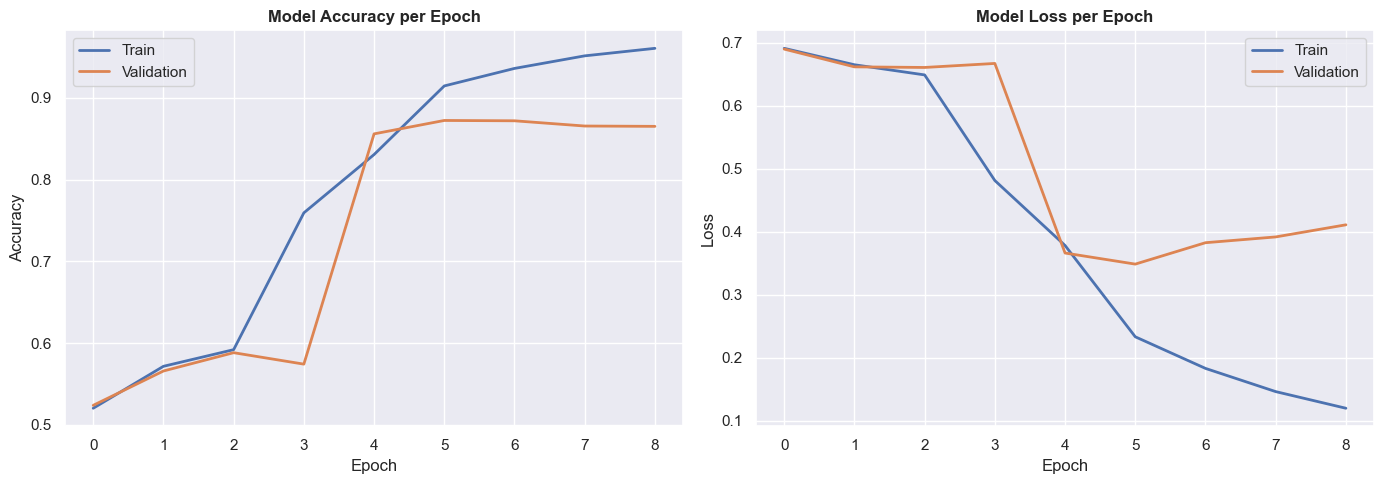

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluate on Test Set

In [8]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Loss:     {test_loss:.4f}')

Test Accuracy: 0.8503
Test Loss:     0.3879


## 8. Confusion Matrix & Classification Report

782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step


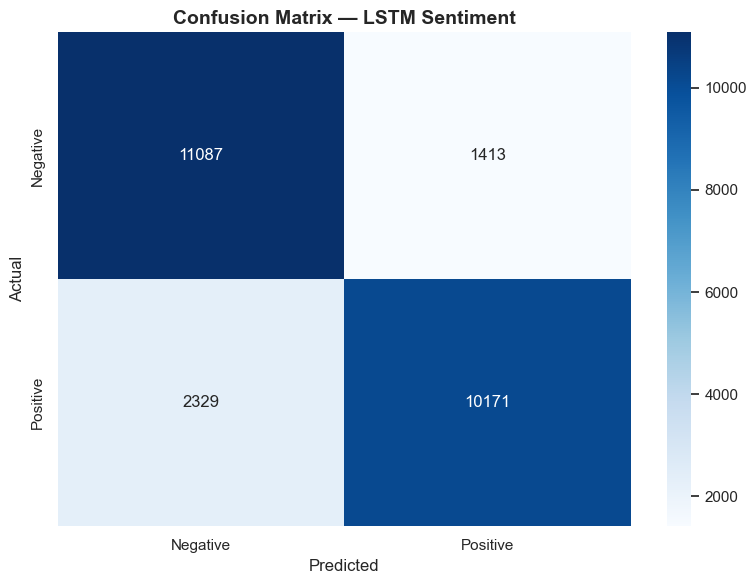

              precision    recall  f1-score   support

    Negative       0.83      0.89      0.86     12500
    Positive       0.88      0.81      0.84     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



In [9]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — LSTM Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

## 9. Predict on Custom Reviews

Test the model on your own sentences.

In [10]:
def predict_sentiment(review_text, model, word_index, max_len=200):
    words = review_text.lower().split()
    encoded = [word_index.get(w, 2) + 3 for w in words]
    padded = keras.preprocessing.sequence.pad_sequences(
        [encoded], maxlen=max_len, padding='post', truncating='post'
    )
    prob = model.predict(padded, verbose=0)[0][0]
    sentiment = 'POSITIVE' if prob > 0.5 else 'NEGATIVE'
    return sentiment, prob

reviews = [
    'This movie was absolutely brilliant and I loved every minute of it',
    'Terrible film waste of time boring and predictable',
    'The acting was great but the story was weak and disappointing',
    'One of the best movies I have ever seen in my life'
]

print('=== Custom Review Predictions ===')
for review in reviews:
    sentiment, prob = predict_sentiment(review, model, word_index)
    print(f'\n Review: {review[:60]}...')
    print(f'  Sentiment: {sentiment} (confidence: {prob:.4f})')

=== Custom Review Predictions ===

 Review: This movie was absolutely brilliant and I loved every minute...
  Sentiment: POSITIVE (confidence: 0.9393)

 Review: Terrible film waste of time boring and predictable...
  Sentiment: NEGATIVE (confidence: 0.0191)

 Review: The acting was great but the story was weak and disappointin...
  Sentiment: NEGATIVE (confidence: 0.1740)

 Review: One of the best movies I have ever seen in my life...
  Sentiment: POSITIVE (confidence: 0.9571)


## 10. Save the Model

In [11]:
model.save('lstm_sentiment.keras')
print('Model saved to lstm_sentiment.keras')

Model saved to lstm_sentiment.keras


## 11. Results Summary

| Metric | Value |
|---|---|
| Test Accuracy | **85.03%** |
| Test Loss | 0.3879 |
| Dataset | IMDB 50K reviews |
| Vocabulary size | 10,000 words |
| Max sequence length | 200 words |
| Architecture | Embedding(128) → SpatialDropout → LSTM(128) → Dense(sigmoid) |

**RNN vs LSTM for this task:**  
A simple RNN would struggle here — movie reviews often have long-range dependencies (a negative word at the start of a 200-word review affects the overall sentiment). LSTM gates retain that context across the full sequence length.

**Generation vs Classification:**  
The `03-rnn-text-generation` project used `return_sequences=True` on all layers because it needed a prediction at every timestep. This LSTM uses the final hidden state only — one prediction per entire review.

**Next:** `05-transformer-from-scratch` — replacing recurrence entirely with self-attention. Transformers process all tokens in parallel (no sequential hidden state), making them faster and better at capturing long-range dependencies.